### 线性回归的从零开始实现

In [15]:
import random
import torch
from d2l import torch as d2l

#### 生成数据集

In [16]:
# def synthetic_data(w, b, num_examples):  #@save
#     """生成y=Xw+b+噪声"""
#     X = torch.normal(0, 1, (num_examples, len(w)))
#     y = torch.matmul(X, w) + b
#     y += torch.normal(0, 0.01, y.shape)
#     return X, y.reshape((-1, 1))

In [17]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [18]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([ 1.9501, -0.0393]) 
label: tensor([8.2090])


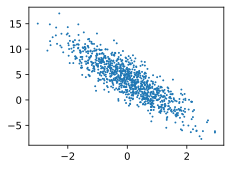

In [19]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

#### 读取数据集

In [20]:
# 该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量。 每个小批量包含一组特征和标签。
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [21]:
batch_size = 10

# for X, y in data_iter(10, features[:23], labels[:23]):
#     print(X.shape)

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.9502, -1.0727],
        [-0.6113, -0.2142],
        [-1.4715,  1.0734],
        [ 1.7274, -1.2852],
        [-1.6609, -0.9738],
        [-0.3589, -0.5161],
        [ 0.8800, -0.2204],
        [ 0.5674,  0.6727],
        [-0.3084,  2.1631],
        [ 0.8702,  0.3631]]) 
 tensor([[ 9.7437],
        [ 3.7131],
        [-2.3855],
        [12.0093],
        [ 4.1846],
        [ 5.2440],
        [ 6.7045],
        [ 3.0547],
        [-3.7852],
        [ 4.6953]])


#### 初始化模型参数

In [22]:
# 通过从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)

# 偏置初始化为0
b = torch.zeros(1, requires_grad=True)

#### 定义模型

In [23]:
# def linreg(X, w, b):  #@save
#     """线性回归模型"""
#     return torch.matmul(X, w) + b

#### 定义损失函数

In [24]:
# def squared_loss(y_hat, y):  #@save
#     """均方损失"""
#     return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2      # reshape 为了保证 y_hat 和 y 的形状完全相同，避免 PyTorch 的广播机制产生错误结果

#### 定义优化算法

In [25]:
# lr 学习率
# 用批量大小（batch_size） 来规范化步长
# def sgd(params, lr, batch_size):  #@save
#     """小批量随机梯度下降"""
#     with torch.no_grad():
#         for param in params:
#             param -= lr * param.grad / batch_size
#             param.grad.zero_()

#### 训练

在每次迭代中，我们读取一小批量训练样本，并通过我们的模型来获得一组预测。 计算完损失后，我们开始反向传播，存储每个参数的梯度。 最后，我们调用优化算法sgd来更新模型参数。

In [26]:
lr = 0.03 # 学习率，超参数
num_epochs = 3 # 迭代周期个数，超参数
net = d2l.linreg # 线性回归模型
loss = d2l.squared_loss # 均方损失函数

# 在每个迭代周期（epoch）中
for epoch in range(num_epochs): 
    # 使用data_iter函数遍历整个数据集，并将训练数据集中所有样本都使用一次（假设样本数能够被批量大小整除）。 
    for X, y in data_iter(batch_size, features, labels): 
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        d2l.sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.052399
epoch 2, loss 0.000229
epoch 3, loss 0.000051


通过比较真实参数和通过训练学到的参数来评估训练的成功程度。 事实上，真实参数和通过训练学到的参数确实非常接近。

In [27]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 0.0013, -0.0009], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0011], grad_fn=<RsubBackward1>)


实验者：设定 true_w、true_b
             ↓
        生成 X 和 y
             ↓
模型：只接收 X 和 y
             ↓
随机初始化 w、b
             ↓
梯度下降更新 w、b
             ↓
检查学到的 w、b 是否接近 true_w、true_b

在真实任务中，顺序则是：

收集真实的 \(X,y\)；
        ↓
假设它们大致满足 \(y=Xw+b+\epsilon\)；
        ↓
随机或置零初始化待学习的 \(w,b\)；
        ↓
最小化预测值与真实标签之间的损失；
        ↓
得到估计参数 \(\hat w,\hat b\)。

噪声分布帮助我们决定“如何衡量误差”；参数初始化分布决定“从哪里开始搜索”；真正推动参数接近答案的是数据产生的梯度。

### 练习

#### 1. 如果我们将权重初始化为零，会发生什么。算法仍然有效吗？

在线性回归中，零初始化通常完全有效；书中使用随机初始化，是为了与后续神经网络的通用训练方式保持一致。

#### 2. 计算二阶导数时可能会遇到什么问题？这些问题可以如何解决？

计算二阶导数需要保留并创建高阶计算图，通常使用 torch.autograd.grad(..., create_graph=True)；参数较多时还会遇到 Hessian 计算和存储成本过高的问题，可改用 Hessian-vector product。

#### 3. 如果样本个数不能被批量大小整除，data_iter函数的行为会有什么变化？

data_iter 的行为确实基本没有变化，它会返回一个较小的末尾批次；但更新参数时必须使用该批次的实际样本数，否则最后一次梯度更新的尺度会偏小。